# 08 — ConvNeXt-Tiny Two-Class ROI-Guided Attention Supervision (Backbone Generalisation)

V2 did not provide evidence that higher resolution and breast-region cropping **alone** improved
classification (its ΔAUC was not statistically clear). This motivates testing whether **explicit
supervision of lesion-focused evidence** improves localisation and/or classification — teaching the
model *where to look*.

**Two-class CAM.** ConvNeXt-Tiny features → a 1×1 conv → a **2-channel** CAM (ch0 = benign evidence,
ch1 = malignant evidence) → global average pooling → 2 logits. Cross-entropy for classification; the
**true-class** CAM is supervised against the **true-class** radiologist ROI. So the model learns where
to look for *both* benign and malignant predictions, and benign masks are used too.

**Attention loss:** `balanced BCE + soft Dice` between `sigmoid(true-class CAM)` and the true-class mask.
`total = CE(logits,label) + λ·attention`.

**Protocol (test-set discipline):**
1. Train λ ∈ {0,0.1,0.5,1.0}; **λ=0 is the identical-architecture control.**
2. Evaluate all four on **validation only**.
3. Select λ by a **predefined rule**: *best validation localisation, provided val AUC is within 0.01 of λ=0.*
4. Touch the **locked test set once** — only for the selected λ, the λ=0 control, and V1/V2 references.

16×16 CAM only (multi-scale is a later option). Run the §7 **smoke test** before the full ablation.

**Purpose.** This is a targeted backbone port of Notebook 06. The patient split,
preprocessing, class-specific masks, attention loss, λ grid, validation-only
selection rule, locked-test policy, metrics and patient-level bootstrap procedure
are unchanged. The only substantive methodological change is the image backbone:
ResNet-50 is replaced by ConvNeXt-Tiny, whose final 768-channel feature map feeds
the same two-class CAM head.



## 1. Config + imports

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os, json, random, shutil
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from PIL import Image, ImageEnhance
import matplotlib, matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             balanced_accuracy_score, confusion_matrix, average_precision_score)

try:
    RESAMPLE_BILINEAR = Image.Resampling.BILINEAR
    RESAMPLE_NEAREST = Image.Resampling.NEAREST
except AttributeError:  # older Pillow
    RESAMPLE_BILINEAR = Image.BILINEAR
    RESAMPLE_NEAREST = Image.NEAREST

PROJECT_DIR = "/content/drive/MyDrive/BreastCancer_dissertation"
DATA_DIR    = os.path.join(PROJECT_DIR, "Data", "CBIS-DDSM")
JPEG_DIR    = os.path.join(DATA_DIR, "jpeg")
OUTPUT_DIR  = os.path.join(PROJECT_DIR, "Results", "convnext_roi_attention_2class")
MODEL_ROOT  = os.path.join(PROJECT_DIR, "Models")

def find_csv(name):
    for c in (os.path.join(DATA_DIR,name), os.path.join(DATA_DIR,"csv",name)):
        if os.path.exists(c): return c
    raise FileNotFoundError(name)

# Reuse the EXACT V2 split so V2 / ResNet ROI / ConvNeXt ROI share patients.
V2_SPLIT_CSV = os.path.join(PROJECT_DIR,"Results","resnet50_v2_breastcrop_512","split_assignments.csv")

TRAIN_CSV, TEST_CSV = "mass_case_description_train_set.csv", "mass_case_description_test_set.csv"
SEED, IMG_SIZE, VAL_FRAC = 42, 512, 0.15
BATCH_SIZE = 8
NUM_WORKERS = 0                    # deterministic, warning-free Colab runs
HEAD_EPOCHS, FINETUNE_EPOCHS, PATIENCE = 4, 15, 5
HEAD_LR, FINETUNE_LR, WEIGHT_DECAY = 1e-3, 1e-5, 1e-4
CROP_PAD_FRAC, MASK_SIZE_TOL, MASK_BINARY_MIN = 0.02, 0.03, 0.60
LAMBDAS = [0.0, 0.1, 0.5, 1.0]
SUP_SIZE = 128
BOOTSTRAP_N = 1000
LAMBDA_AUC_TOLERANCE = 0.01        # selected lambda must be within this of lambda=0 val AUC
AUC_NONINFERIORITY_MARGIN = 0.01   # classification non-inferior if delta AUC lower bound > -margin

PREPROCESS_VERSION = "convnext_attn2c_v2"   # bumped: validated cache + exact test-split checks
FORCE_REBUILD_CACHE = False
CACHE_DIR = f"/content/cbis_convnext_attn2c_{PREPROCESS_VERSION}_{IMG_SIZE}_pad{int(CROP_PAD_FRAC*1000):03d}"
RUN_TAG = f"convnext_tiny_roi_attn2c_{PREPROCESS_VERSION}_seed{SEED}"
MODEL_DIR = os.path.join(MODEL_ROOT, "convnext_roi_attention_2class", RUN_TAG)

for d in (OUTPUT_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

if FORCE_REBUILD_CACHE and os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)
for sub in ("img","mask_b","mask_m","meta"):
    os.makedirs(os.path.join(CACHE_DIR,sub), exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Model output directory:", MODEL_DIR)

Device: cuda
Model output directory: /content/drive/MyDrive/BreastCancer_dissertation/Models/convnext_roi_attention_2class/convnext_tiny_roi_attn2c_convnext_attn2c_v2_seed42


## 2. Image-level dataset — **class-specific** ROI paths + full metadata
Splits each abnormality's ROI by its own pathology, so benign and malignant masks stay separate
(mixed-pathology rule). Retains density/shape/margins/assessment for later subgroup analysis.

In [3]:
ALLOWED={"BENIGN","BENIGN_WITHOUT_CALLBACK","MALIGNANT"}
def uid_from(p): return str(p).split("/")[-2]
def jpegs_from(mp):
    folder=os.path.join(JPEG_DIR, uid_from(mp))
    if not os.path.isdir(folder): return []
    return [os.path.join(folder,f) for f in sorted(os.listdir(folder))
            if f.lower().endswith((".jpg",".jpeg",".png"))]
def first_jpeg(mp):
    fs=jpegs_from(mp); return fs[0] if fs else None
def join_unique(v):
    out=[]
    for x in v:
        if isinstance(x,str) and x and x not in out: out.append(x)
    return "||".join(out)

def build_df(case_csv, split):
    raw=pd.read_csv(find_csv(case_csv))
    assert set(raw["pathology"].dropna().astype(str).str.upper()).issubset(ALLOWED)
    raw["is_malignant_abn"]=(raw["pathology"].astype(str).str.upper()=="MALIGNANT")
    raw["full_jpeg"]=raw["image file path"].apply(first_jpeg)
    raw["roi_b"]=np.where(~raw.is_malignant_abn, raw["ROI mask file path"], None)  # benign abn -> benign mask
    raw["roi_m"]=np.where( raw.is_malignant_abn, raw["ROI mask file path"], None)  # malignant abn -> malignant mask
    df=(raw.dropna(subset=["full_jpeg"])
          .groupby(["patient_id","left or right breast","image view"], as_index=False)
          .agg(full_jpeg=("full_jpeg","first"),
               label=("is_malignant_abn","max"),                      # image malignant if ANY abn malignant
               n_abn=("is_malignant_abn","size"),
               n_malignant_abn=("is_malignant_abn","sum"),
               benign_roi=("roi_b", join_unique),
               malignant_roi=("roi_m", join_unique),
               breast_density=("breast_density","first"),
               assessment=("assessment", lambda x:"; ".join(sorted(set(map(str,x))))),
               mass_shape=("mass shape", lambda x:"; ".join(sorted(set(map(str,x))))),
               mass_margins=("mass margins", lambda x:"; ".join(sorted(set(map(str,x)))))))
    df["label"]=df["label"].astype(int)
    df["mixed_pathology"]=((df.n_malignant_abn>0)&(df.n_malignant_abn<df.n_abn)).astype(int)
    df["sample_id"]=(df.patient_id.astype(str)+"|"+df["left or right breast"].astype(str)+"|"+df["image view"].astype(str))
    return df.reset_index(drop=True)

train_all=build_df(TRAIN_CSV,"development"); test_df=build_df(TEST_CSV,"locked_test")
print("mixed-pathology mammograms — train:", int(train_all.mixed_pathology.sum()),
      "| test:", int(test_df.mixed_pathology.sum()))
print("(these are classified malignant; only the malignant ROI supervises the malignant CAM)")

mixed-pathology mammograms — train: 6 | test: 2
(these are classified malignant; only the malignant ROI supervises the malignant CAM)


## 3. Train/val split — reuse V2's exact split if available

In [4]:
# STRICT: the ConvNeXt ROI models must use exactly V2's patients. No silent re-split.
if not os.path.exists(V2_SPLIT_CSV):
    raise FileNotFoundError(f"V2 split not found: {V2_SPLIT_CSV}\n"
        "Do not generate a new split — V1/V2/ResNet-ROI/ConvNeXt-ROI must share patients. "
        "Run the V2 notebook first (it saves split_assignments.csv).")

v2 = pd.read_csv(V2_SPLIT_CSV)
assert {"sample_id","split"}.issubset(v2.columns), "V2 split missing sample_id/split"
v2["split"] = (
    v2["split"].astype(str).str.strip().str.lower()
      .replace({"val":"validation","valid":"validation","locked test":"locked_test"})
)

tr_ids = set(v2.loc[v2.split=="train","sample_id"])
va_ids = set(v2.loc[v2.split=="validation","sample_id"])
te_ids = set(v2.loc[v2.split.isin(["locked_test","test"]),"sample_id"])

train_df = train_all[train_all.sample_id.isin(tr_ids)].reset_index(drop=True)
val_df   = train_all[train_all.sample_id.isin(va_ids)].reset_index(drop=True)

assert set(train_df.sample_id) == tr_ids, "train sample IDs differ from saved V2 split"
assert set(val_df.sample_id) == va_ids, "validation sample IDs differ from saved V2 split"
assert (set(train_df.sample_id) | set(val_df.sample_id)) == set(train_all.sample_id), \
    "some development images are missing from the V2 assignments"
assert set(train_df.sample_id).isdisjoint(set(val_df.sample_id)), "train/validation sample overlap"

if te_ids:
    assert set(test_df.sample_id) == te_ids, (
        f"locked test mismatch: current={len(test_df)} samples, saved V2={len(te_ids)} samples"
    )

for _d in (train_df, val_df, test_df):
    assert not _d.sample_id.duplicated().any()

for a,b in [(train_df,val_df),(train_df,test_df),(val_df,test_df)]:
    assert set(a.patient_id).isdisjoint(set(b.patient_id)), "patient leakage across splits"

split_record = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="validation"),
    test_df.assign(split="locked_test"),
])[["sample_id","patient_id","label","split"]]
split_record.to_csv(os.path.join(OUTPUT_DIR,"exact_split_assignments.csv"), index=False)

print(f"Exact V2 split confirmed — train {len(train_df)} ({train_df.patient_id.nunique()} pts) | "
      f"val {len(val_df)} ({val_df.patient_id.nunique()} pts) | "
      f"test {len(test_df)} ({test_df.patient_id.nunique()} pts)")

Exact V2 split confirmed — train 1051 (592 pts) | val 180 (99 pts) | test 361 (201 pts)


## 4. Preprocess + register **class-specific** masks, cache

In [5]:
def otsu(g):
    h=np.bincount(g.ravel(),minlength=256).astype(float); p=h/max(g.size,1)
    om=np.cumsum(p); mu=np.cumsum(p*np.arange(256)); mt=mu[-1]
    s=(mt*om-mu)**2/np.maximum(om*(1-om),1e-12); s[(om<=0)|(om>=1)]=0; return int(np.argmax(s))
def bbox(g,pad=CROP_PAD_FRAC):
    h,w=g.shape; m=g>max(otsu(g),5)
    m=ndimage.binary_opening(m,structure=np.ones((3,3))); m=ndimage.binary_closing(m,structure=np.ones((7,7)))
    lab,n=ndimage.label(m)
    if n==0: return (0,0,w,h)
    c=np.bincount(lab.ravel()); c[0]=0; ys,xs=np.where(lab==c.argmax())
    if len(xs)==0: return (0,0,w,h)
    q=int(round(pad*max(h,w)))
    return (max(int(xs.min())-q,0),max(int(ys.min())-q,0),min(int(xs.max())+1+q,w),min(int(ys.max())+1+q,h))
def _cpr(a,bb,rs):
    l,t,r,b=bb; cr=Image.fromarray(a).crop((l,t,r,b)); cw,ch=cr.size; sd=max(cw,ch)
    cv=Image.new("L",(sd,sd),0); cv.paste(cr,((sd-cw)//2,(sd-ch)//2)); return np.array(cv.resize((IMG_SIZE,IMG_SIZE),rs))
def crop_img(g,bb): return _cpr(g,bb,RESAMPLE_BILINEAR).astype(np.uint8)
def crop_mask(m,bb): return (_cpr(m,bb,RESAMPLE_NEAREST)>127).astype(np.uint8)
def load_gray(p): return np.array(Image.open(p).convert("L"),dtype=np.uint8)

def register_masks(roi_field, shape, tol=MASK_SIZE_TOL, bmin=MASK_BINARY_MIN):
    fh,fw=shape; union=np.zeros((fh,fw),np.uint8); found=False
    for mp in str(roi_field).split("||"):
        if not mp or mp=="nan": continue
        for f in jpegs_from(mp):
            a=load_gray(f); h,w=a.shape
            if abs(h-fh)/max(fh,1)>tol or abs(w-fw)/max(fw,1)>tol: continue
            if float(np.mean((a<20)|(a>235)))<bmin: continue
            if (h,w)!=(fh,fw): a=np.array(Image.fromarray(a).resize((fw,fh),RESAMPLE_NEAREST))
            m=a>127
            if m.mean()>0.5: m=~m
            m=m.astype(np.uint8)
            if m.sum()==0: continue
            union=np.maximum(union,m); found=True
    return union if (found and union.sum()>0) else None

def _safe_sid(sid): return sid.replace("|","_")
def ip(sid): return os.path.join(CACHE_DIR,"img",_safe_sid(sid)+".png")
def bp(sid): return os.path.join(CACHE_DIR,"mask_b",_safe_sid(sid)+".png")
def mp_(sid):return os.path.join(CACHE_DIR,"mask_m",_safe_sid(sid)+".png")
def meta_p(sid): return os.path.join(CACHE_DIR,"meta",_safe_sid(sid)+".json")

def cache_signature(row):
    return {
        "preprocess_version": PREPROCESS_VERSION,
        "sample_id": str(row.sample_id),
        "full_jpeg": str(row.full_jpeg),
        "benign_roi": str(row.benign_roi),
        "malignant_roi": str(row.malignant_roi),
        "img_size": int(IMG_SIZE),
        "crop_pad_frac": float(CROP_PAD_FRAC),
        "mask_size_tol": float(MASK_SIZE_TOL),
        "mask_binary_min": float(MASK_BINARY_MIN),
    }

def cache_valid(row):
    sid=row.sample_id
    if not all(os.path.exists(x) for x in (ip(sid),bp(sid),mp_(sid),meta_p(sid))):
        return False
    try:
        with open(meta_p(sid), "r") as f:
            old=json.load(f)
    except Exception:
        return False
    return old == cache_signature(row)

def write_cache_meta(row):
    with open(meta_p(row.sample_id), "w") as f:
        json.dump(cache_signature(row), f, indent=2)

def build_cache(df,name):
    recs=[]; rebuilt=0
    for row in tqdm(df.itertuples(), total=len(df), desc=f"cache {name}"):
        sid=row.sample_id
        if not cache_valid(row):
            g=load_gray(row.full_jpeg); bb=bbox(g)
            Image.fromarray(crop_img(g,bb)).save(ip(sid))
            for field, path in [(row.benign_roi,bp(sid)),(row.malignant_roi,mp_(sid))]:
                full=register_masks(field,g.shape)
                m=crop_mask(full*255,bb) if full is not None else np.zeros((IMG_SIZE,IMG_SIZE),np.uint8)
                Image.fromarray((m*255).astype(np.uint8)).save(path)
            write_cache_meta(row); rebuilt += 1
        hb=bool(np.array(Image.open(bp(sid))).sum()>0); hm=bool(np.array(Image.open(mp_(sid))).sum()>0)
        recs.append({"sample_id":sid,"has_benign_mask":hb,"has_malignant_mask":hm})
    print(f"{name}: rebuilt {rebuilt}/{len(df)} cached samples")
    out=df.merge(pd.DataFrame(recs), on="sample_id")
    # true-class mask availability: benign image needs benign mask; malignant image needs malignant mask
    out["has_trueclass_mask"]=np.where(out.label==1, out.has_malignant_mask, out.has_benign_mask)
    return out

train_df=build_cache(train_df,"train"); val_df=build_cache(val_df,"val"); test_df=build_cache(test_df,"test")
cov_tbl=[]
for n,d in [("train",train_df),("val",val_df),("test",test_df)]:
    cov=d.has_trueclass_mask.mean()
    cov_tbl.append({"split":n,"true_class_cov":cov,
                    "benign_cov":d[d.label==0].has_benign_mask.mean(),
                    "malignant_cov":d[d.label==1].has_malignant_mask.mean()})
    print(f"{n}: true-class mask coverage {cov:.1%} "
          f"(benign {d[d.label==0].has_benign_mask.mean():.1%}, malignant {d[d.label==1].has_malignant_mask.mean():.1%})")
    assert cov>0.90, f"Unexpectedly low true-class mask coverage in {n}: {cov:.1%} — re-audit before training."
pd.DataFrame(cov_tbl).to_csv(os.path.join(OUTPUT_DIR,"mask_coverage_by_split.csv"),index=False)

cache train:   0%|          | 0/1051 [00:00<?, ?it/s]

train: rebuilt 1051/1051 cached samples


cache val:   0%|          | 0/180 [00:00<?, ?it/s]

val: rebuilt 180/180 cached samples


cache test:   0%|          | 0/361 [00:00<?, ?it/s]

test: rebuilt 361/361 cached samples
train: true-class mask coverage 95.0% (benign 92.9%, malignant 97.2%)
val: true-class mask coverage 93.3% (benign 88.0%, malignant 97.9%)
test: true-class mask coverage 96.4% (benign 94.0%, malignant 100.0%)


### 4a. Class-specific mask re-audit (train only)
Separating benign/malignant ROIs changed the mask-building logic, so re-verify contours land on the correct-class lesion.

In [6]:
# --- augmentation (defined here because the §4a mask audit augments image+mask together) ---
def aug_pair(img,mask):
    if random.random()<0.5: img=TF.hflip(img); mask=TF.hflip(mask)
    if random.random()<0.8:
        a=random.uniform(-8,8); dx=int(.03*img.size[0]); dy=int(.03*img.size[1]); tr=(random.randint(-dx,dx),random.randint(-dy,dy))
        img=TF.affine(img,angle=a,translate=tr,scale=1.,shear=[0.,0.],interpolation=InterpolationMode.BILINEAR,fill=0)
        mask=TF.affine(mask,angle=a,translate=tr,scale=1.,shear=[0.,0.],interpolation=InterpolationMode.NEAREST,fill=0)
    if random.random()<0.5: img=ImageEnhance.Brightness(img).enhance(random.uniform(.9,1.1))
    if random.random()<0.5: img=ImageEnhance.Contrast(img).enhance(random.uniform(.9,1.15))
    return img,mask

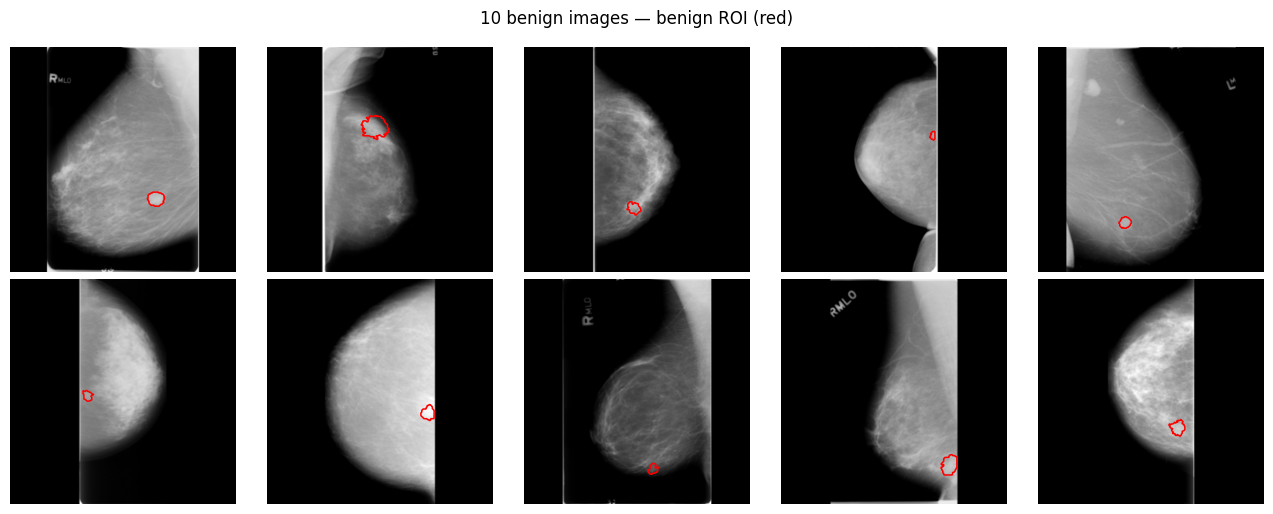

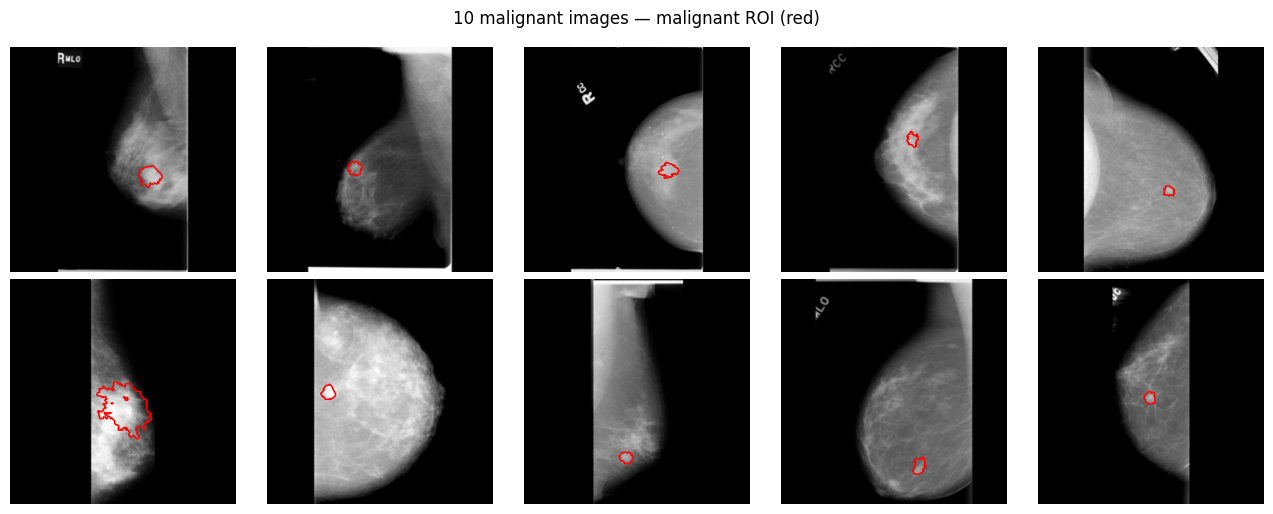

mixed-pathology train images with malignant mask: 6


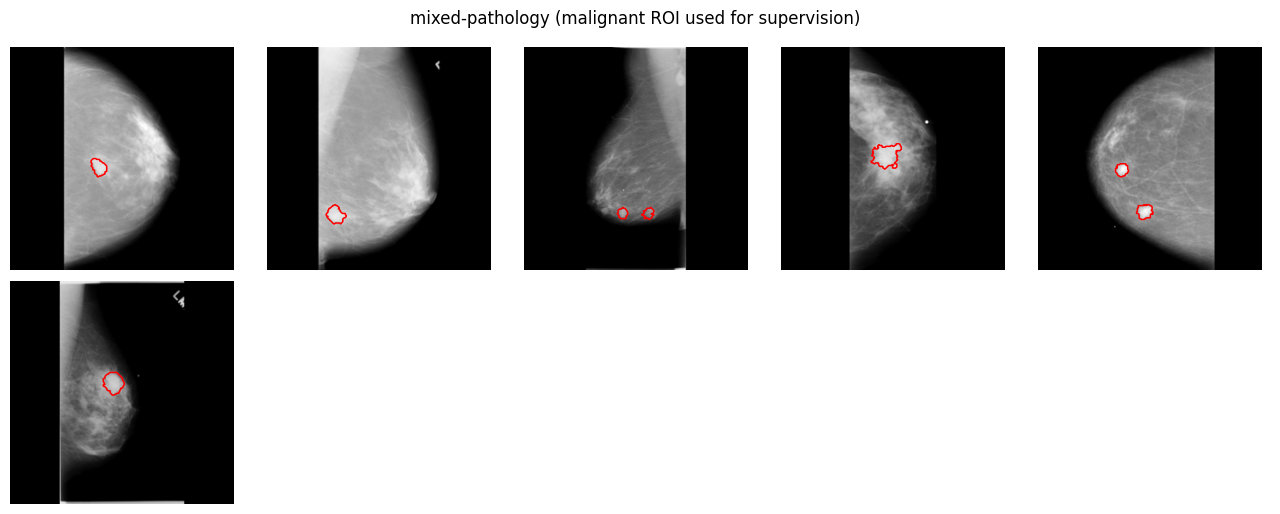

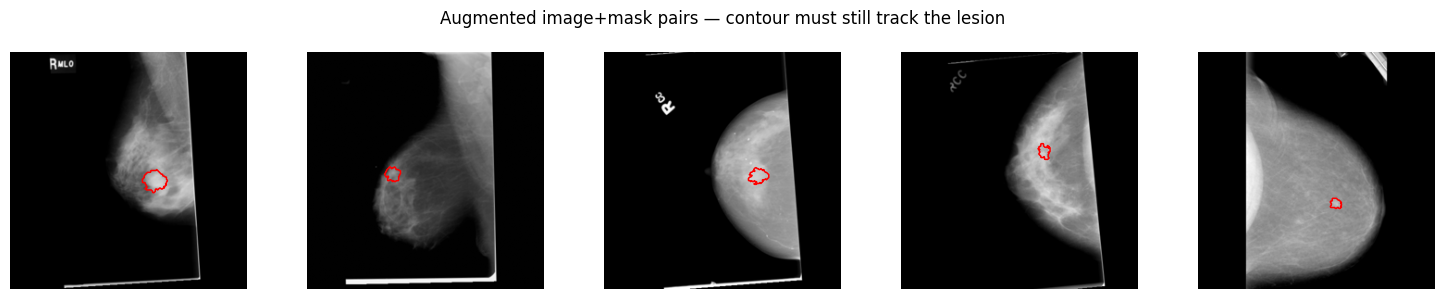

train: true-class 95.0% | benign 92.9% | malignant 97.2%
val: true-class 93.3% | benign 88.0% | malignant 97.9%
test: true-class 96.4% | benign 94.0% | malignant 100.0%
>> GATE: confirm every red contour (incl. augmented) sits on the correct-class lesion before the full ablation.


In [7]:
def _panel(ax,sid,which,title=""):
    img=Image.open(ip(sid)).convert("L").resize((256,256))
    m=np.array(Image.open((mp_ if which=="malignant" else bp)(sid)).convert("L").resize((256,256),RESAMPLE_NEAREST))>127
    ax.imshow(img,cmap="gray"); ax.contour(m,levels=[.5],colors="red",linewidths=1.1); ax.axis("off")
    if title: ax.set_title(title,fontsize=8)

ben=train_df[(train_df.label==0)&train_df.has_benign_mask]
mal=train_df[(train_df.label==1)&train_df.has_malignant_mask]
ben=ben.sample(min(10,len(ben)),random_state=SEED); mal=mal.sample(min(10,len(mal)),random_state=SEED)
def grid(rows_df, which, header):
    n=len(rows_df); cols=5; r=int(np.ceil(n/cols))
    fig,ax=plt.subplots(r,cols,figsize=(2.6*cols,2.6*r)); ax=np.atleast_2d(ax)
    for k,sid in enumerate(rows_df.sample_id):
        _panel(ax[k//cols,k%cols],sid,which)
    for k in range(n,r*cols): ax[k//cols,k%cols].axis("off")
    fig.suptitle(header); plt.tight_layout(); plt.show()
grid(ben,"benign","10 benign images — benign ROI (red)")
grid(mal,"malignant","10 malignant images — malignant ROI (red)")

# mixed-pathology cases (classified malignant; malignant ROI supervises)
mixed=train_df[(train_df.mixed_pathology==1)&train_df.has_malignant_mask]
print(f"mixed-pathology train images with malignant mask: {len(mixed)}")
if len(mixed):
    grid(mixed.sample(min(6,len(mixed)),random_state=SEED),"malignant",
         "mixed-pathology (malignant ROI used for supervision)")

# augmented image+mask pairs — verify they stay aligned after geometric augmentation
sample_ids=list(mal.sample_id)[:5]
fig,ax=plt.subplots(1,5,figsize=(15,3))
for a,sid in zip(ax,sample_ids):
    img=Image.open(ip(sid)).convert("L"); msk=Image.open(mp_(sid)).convert("L")
    ai,am=aug_pair(img,msk)
    ai=ai.resize((256,256)); am=(np.array(am.resize((256,256),RESAMPLE_NEAREST))>127)
    a.imshow(ai,cmap="gray"); a.contour(am,levels=[.5],colors="red",linewidths=1.1); a.axis("off")
fig.suptitle("Augmented image+mask pairs — contour must still track the lesion"); plt.tight_layout(); plt.show()

# coverage by split and class (printed for the record)
for n,d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{n}: true-class {d.has_trueclass_mask.mean():.1%} | benign {d[d.label==0].has_benign_mask.mean():.1%} | malignant {d[d.label==1].has_malignant_mask.mean():.1%}")
print(">> GATE: confirm every red contour (incl. augmented) sits on the correct-class lesion before the full ablation.")

## 5. Dataset / loaders — image, label, true-class mask, has_mask

In [8]:
MEAN=torch.tensor([0.485,0.456,0.406]).view(3,1,1); STD=torch.tensor([0.229,0.224,0.225]).view(3,1,1)
# aug_pair(img,mask) is defined earlier (moved above the §4a audit that uses it)

class AttnDS(Dataset):
    def __init__(self,df,train=False): self.df=df.reset_index(drop=True); self.train=train
    def __len__(self): return len(self.df)
    def __getitem__(self,i):
        r=self.df.iloc[i]
        img=Image.open(ip(r.sample_id)).convert("L")
        tc_mask_path = mp_(r.sample_id) if r.label==1 else bp(r.sample_id)   # TRUE-class mask
        mask=Image.open(tc_mask_path).convert("L")
        if self.train: img,mask=aug_pair(img,mask)
        t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        m=torch.from_numpy((np.array(mask,np.float32)>127).astype(np.float32)).unsqueeze(0)
        return {"image":t.float(),"label":torch.tensor(int(r.label)),
                "mask":m,"has_mask":torch.tensor(float(r.has_trueclass_mask)),
                "sample_id":r.sample_id,"patient_id":str(r.patient_id)}

def seed_worker(w): s=torch.initial_seed()%(2**32); np.random.seed(s); random.seed(s)
def make_train_loader(seed):
    gen=torch.Generator(); gen.manual_seed(seed)                    # FIX: fresh generator per λ
    return DataLoader(AttnDS(train_df,True),batch_size=BATCH_SIZE,shuffle=True,
                      num_workers=NUM_WORKERS,pin_memory=True,worker_init_fn=seed_worker,generator=gen)
val_loader =DataLoader(AttnDS(val_df),  batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
test_loader=DataLoader(AttnDS(test_df), batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)

## 6. ConvNeXt-Tiny two-class CAM model + BCE-Dice attention loss

In [9]:
class ConvNeXtCAM2(nn.Module):
    """ConvNeXt-Tiny with a two-class 1×1 CAM head.

    For a 512×512 input, torchvision ConvNeXt-Tiny produces a
    768-channel 16×16 final feature map. Channel 0 of the CAM is benign
    evidence and channel 1 is malignant evidence.
    """
    def __init__(self, n_classes=2):
        super().__init__()
        bb = models.convnext_tiny(
            weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )
        self.features = bb.features
        self.cam_conv = nn.Conv2d(768, n_classes, kernel_size=1)

    def forward(self, x, return_cam=False):
        f = self.features(x)                                   # B,768,16,16
        cam = self.cam_conv(f)                                 # B,2,16,16
        logits = F.adaptive_avg_pool2d(cam, 1).flatten(1)     # B,2
        return (logits, cam) if return_cam else logits


def freeze_bn(m):
    # ConvNeXt uses LayerNorm rather than BatchNorm, but retaining this
    # helper keeps the training protocol/API identical to Notebook 06.
    for mod in m.modules():
        if isinstance(mod, nn.BatchNorm2d):
            mod.eval()
            for p in mod.parameters():
                p.requires_grad = False


def set_trainable(m, stage):
    """Head-only first; then unfreeze only ConvNeXt's final stage."""
    for name, p in m.named_parameters():
        p.requires_grad = (
            name.startswith("cam_conv")
            or (stage == "finetune" and name.startswith("features.7"))
        )


def soft_dice(prob, target, eps=1.):
    p = prob.flatten(1)
    t = target.flatten(1)
    inter = (p * t).sum(1)
    return (1 - (2 * inter + eps) / (p.sum(1) + t.sum(1) + eps)).mean()


def balanced_bce_logits(logits, target, eps=1e-6):
    # Numerically stable under AMP; balances small lesion foreground
    # against the much larger background.
    pos = target.mean(dim=(1, 2, 3), keepdim=True).clamp(eps, 1 - eps)
    w = (0.5 / pos) * target + (0.5 / (1 - pos)) * (1 - target)
    raw = F.binary_cross_entropy_with_logits(
        logits, target, reduction="none"
    )
    return (w * raw).mean()


def attention_loss(cam, mask, label, has_mask, sup=SUP_SIZE):
    idx = torch.arange(label.size(0), device=label.device)
    true_class_cam = cam[idx, label].unsqueeze(1)               # B,1,16,16
    selected = has_mask.view(-1) == 1

    if selected.sum() == 0:
        return cam.new_tensor(0.0)

    logits = F.interpolate(
        true_class_cam[selected],
        size=(sup, sup),
        mode="bilinear",
        align_corners=False,
    )

    # Preserve soft fractional targets after area downsampling.
    target = F.interpolate(
        mask[selected],
        size=(sup, sup),
        mode="area",
    ).clamp(0.0, 1.0)

    return (
        0.5 * balanced_bce_logits(logits, target)
        + 0.5 * soft_dice(torch.sigmoid(logits), target)
    )


@torch.no_grad()
def assert_convnext_cam_shape(size=IMG_SIZE):
    probe = torch.zeros(1, 3, size, size, device=device)
    m = ConvNeXtCAM2().to(device).eval()
    logits, cam = m(probe, return_cam=True)
    assert logits.shape == (1, 2), f"Unexpected logits shape: {tuple(logits.shape)}"
    assert cam.shape[1] == 2, f"CAM head should produce two class channels, got {cam.shape[1]}"
    assert cam.shape[2:] == (size // 32, size // 32), (
        f"Unexpected CAM spatial size {tuple(cam.shape[2:])}; expected {(size // 32, size // 32)} "
        "for ConvNeXt-Tiny stride-32 at this input size."
    )
    print(f"ConvNeXt CAM shape check passed: logits {tuple(logits.shape)}, CAM {tuple(cam.shape)}")
    del m, probe, logits, cam
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


assert_convnext_cam_shape()


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 166MB/s]


ConvNeXt CAM shape check passed: logits (1, 2), CAM (1, 2, 16, 16)


## 7. Localisation & classification helpers (defined BEFORE the smoke test)

In [10]:
@torch.no_grad()
def cam_map(m,image_tensor,true_class,size=SUP_SIZE):
    logits,cam=m(image_tensor.unsqueeze(0).to(device),return_cam=True)
    c=F.interpolate(cam[:,true_class:true_class+1],size=(size,size),mode="bilinear",align_corners=False).squeeze().cpu().numpy()
    c-=c.min()
    if c.max()>0: c/=c.max()
    return c

def localisation(m, df):
    """True-class CAM vs true-class mask, for images WITH a true-class mask. Split benign/malignant."""
    res={}
    for name,sub in [("all",df[df.has_trueclass_mask]),
                     ("malignant",df[(df.label==1)&df.has_trueclass_mask]),
                     ("benign",df[(df.label==0)&df.has_trueclass_mask])]:
        pg=[]; pauc=[]; pap=[]; dice=[]; chance=[]
        for r in sub.itertuples():
            img=Image.open(ip(r.sample_id)).convert("L")
            t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
            cam=cam_map(m,t.float(),int(r.label))
            mpath_=mp_(r.sample_id) if r.label==1 else bp(r.sample_id)
            mask=np.array(Image.open(mpath_).convert("L").resize((SUP_SIZE,SUP_SIZE),RESAMPLE_NEAREST))>127
            if mask.sum()==0: continue
            peak=np.unravel_index(cam.argmax(),cam.shape); pg.append(int(mask[peak]))
            if 0<mask.sum()<mask.size:
                pauc.append(roc_auc_score(mask.flatten(),cam.flatten()))
                pap.append(average_precision_score(mask.flatten(),cam.flatten()))  # robust to bg imbalance
            cb=cam>=0.5; inter=np.logical_and(cb,mask).sum()
            dice.append(2*inter/(cb.sum()+mask.sum()) if (cb.sum()+mask.sum()) else 0.)
            chance.append(mask.mean())
        res[name]={"n":len(pg),"pointing_game":np.mean(pg) if pg else np.nan,
                   "pg_chance":np.mean(chance) if chance else np.nan,
                   "pixel_auc":np.mean(pauc) if pauc else np.nan,
                   "pixel_ap":np.mean(pap) if pap else np.nan,
                   "dice@0.5":np.mean(dice) if dice else np.nan}
    return res

def metrics_cls(y,p,th):
    y=np.asarray(y).astype(int); p=np.asarray(p,float); pr=(p>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pr,labels=[0,1]).ravel()
    return {"roc_auc":roc_auc_score(y,p),"pr_auc":average_precision_score(y,p),
            "sensitivity":tp/(tp+fn) if (tp+fn) else np.nan,
            "specificity":tn/(tn+fp) if (tn+fp) else np.nan,
            "balanced_acc":balanced_accuracy_score(y,pr),"f1":f1_score(y,pr,zero_division=0)}
def pick_threshold(vp):
    best=(0.5,-1)
    for th in np.linspace(0.05,0.95,91):
        mm=metrics_cls(vp.y_true,vp.p_malignant,th); j=mm["sensitivity"]+mm["specificity"]-1
        if j>best[1]: best=(th,j)
    return best[0]

def localisation_per_case(m, df):
    m.eval(); rows=[]
    for r in df[df.has_trueclass_mask].itertuples():
        img=Image.open(ip(r.sample_id)).convert("L")
        t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        cam=cam_map(m,t.float(),int(r.label))
        mpath_=mp_(r.sample_id) if r.label==1 else bp(r.sample_id)
        mask=np.array(Image.open(mpath_).convert("L").resize((SUP_SIZE,SUP_SIZE),RESAMPLE_NEAREST))>127
        if mask.sum()==0: continue
        peak=np.unravel_index(cam.argmax(),cam.shape); both=0<mask.sum()<mask.size
        cb=cam>=0.5; inter=np.logical_and(cb,mask).sum()
        rows.append({"sample_id":r.sample_id,"patient_id":str(r.patient_id),"label":int(r.label),
                     "pointing_game":int(mask[peak]),
                     "pixel_auc":roc_auc_score(mask.flatten(),cam.flatten()) if both else np.nan,
                     "pixel_ap":average_precision_score(mask.flatten(),cam.flatten()) if both else np.nan,
                     "dice":2*inter/(cb.sum()+mask.sum()) if (cb.sum()+mask.sum()) else 0.})
    return pd.DataFrame(rows)

def paired_loc_delta(a,b,col,n_boot=BOOTSTRAP_N,seed=SEED):
    mg=a[["sample_id","patient_id",col]].rename(columns={col:"a"}).merge(
        b[["sample_id",col]].rename(columns={col:"b"}),on="sample_id").dropna()
    rng=np.random.default_rng(seed); by={k:g for k,g in mg.groupby("patient_id")}; pids=np.array(list(by)); ds=[]
    for _ in range(n_boot):
        bs=pd.concat([by[pp] for pp in rng.choice(pids,len(pids),replace=True)],ignore_index=True)
        ds.append((bs.a-bs.b).mean())
    ds=np.array(ds); return float((mg.a-mg.b).mean()), float(np.quantile(ds,.025)), float(np.quantile(ds,.975))

## 7. ⚡ Smoke test — run FIRST (λ∈{0,0.1}, tiny epochs)
Confirms both models train, attention loss decreases, masks align, metrics don't error. **Set
`SMOKE=False` afterwards for the real run.**

In [11]:
ce = nn.CrossEntropyLoss()

@torch.no_grad()
def predict(m,loader):
    m.eval(); rows=[]
    for b in loader:
        pr=torch.softmax(m(b["image"].to(device)),1)[:,1].cpu().numpy()
        for sid,pid,y,pp in zip(b["sample_id"],b["patient_id"],b["label"].numpy(),pr):
            rows.append({"sample_id":sid,"patient_id":pid,"y_true":int(y),"p_malignant":float(pp)})
    return pd.DataFrame(rows)

def run_stage(m,lam,epochs,opt,sched,start,loader):
    best=-np.inf; best_state=None; patience=PATIENCE; hist=[]
    scaler=torch.amp.GradScaler("cuda",enabled=(device.type=="cuda"))
    for e in range(1,epochs+1):
        m.train(); freeze_bn(m); cl=al=0.; n=0; nsup=0
        for b in tqdm(loader,leave=False,desc=f"λ={lam} ep{start+e}"):
            x=b["image"].to(device); y=b["label"].to(device)
            mask=b["mask"].to(device); hm=b["has_mask"].to(device)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda",enabled=(device.type=="cuda")):
                logits,cam=m(x,return_cam=True)
                lc=ce(logits,y); la=attention_loss(cam,mask,y,hm) if lam>0 else cam.new_tensor(0.0)
                loss=lc+lam*la
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            bs=x.size(0); sup=int(hm.sum().item())
            cl+=lc.item()*bs; n+=bs
            if sup>0: al+=la.detach().item()*sup; nsup+=sup       # weight att loss by supervised images only
        vp=predict(m,val_loader); auc=roc_auc_score(vp.y_true,vp.p_malignant)
        if sched: sched.step(auc)
        hist.append({"lambda":lam,"epoch":start+e,"cls_loss":cl/max(n,1),
                     "att_loss":al/max(nsup,1),"n_supervised":nsup,"val_auc":auc})
        print(f"  λ={lam} ep{start+e:02d} | cls {cl/max(n,1):.4f} | att {al/max(nsup,1):.4f} | "
              f"supervised {nsup} | val AUC {auc:.4f}")
        if auc>best: best=auc; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}; patience=PATIENCE
        else:
            patience-=1
            if patience<=0: break
    if best_state: m.load_state_dict(best_state)
    return hist,best

def checkpoint_path(lam, ckpt_suffix=""):
    return os.path.join(MODEL_DIR, f"convnext_tiny_cam2_lambda{lam}{ckpt_suffix}.pth")

def train_lambda(lam, head_ep, ft_ep, ckpt_suffix=""):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    loader=make_train_loader(SEED)                       # fresh identical stream per λ
    m=ConvNeXtCAM2().to(device); hist=[]; best=-np.inf; best_state=None
    set_trainable(m,"head")
    opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=HEAD_LR,weight_decay=WEIGHT_DECAY)
    h,b=run_stage(m,lam,head_ep,opt,None,0,loader); hist+=h
    if b>best: best=b; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}
    set_trainable(m,"finetune")
    opt=torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],lr=FINETUNE_LR,weight_decay=WEIGHT_DECAY)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="max",factor=0.5,patience=2)
    h,b=run_stage(m,lam,ft_ep,opt,sched,len(hist),loader); hist+=h
    if b>best: best=b; best_state={k:v.detach().cpu() for k,v in m.state_dict().items()}
    m.load_state_dict(best_state)
    path=checkpoint_path(lam, ckpt_suffix); torch.save(best_state,path)
    return m,pd.DataFrame(hist),best,path

SMOKE = False
if SMOKE:
    print(">> SMOKE TEST (λ=0 and λ=0.1, 1+2 epochs). Returns outputs for review; does NOT declare success blindly.")
    smoke_ok=True
    for lam in [0.0, 0.1]:
        sm,hist,best,path = train_lambda(lam, head_ep=1, ft_ep=2, ckpt_suffix="_smoke")
        display(hist)
        vp = predict(sm, val_loader); loc = localisation(sm, val_df)["malignant"]
        assert len(vp)==len(val_df), "prediction count mismatch"
        assert vp.p_malignant.between(0,1).all() and np.isfinite(vp.p_malignant).all(), "invalid probabilities"
        print(f"   λ={lam}: val AUC {best:.4f} | val malignant PG {loc['pointing_game']:.3f} "
              f"| pixel_ap {loc['pixel_ap']:.3f}")
        if lam>0:
            att = hist["att_loss"].dropna().to_numpy()
            assert len(att)>=2 and np.isfinite(att).all(), "attention-loss history missing/invalid"
            print(f"      attention loss: {att[0]:.4f} -> {att[-1]:.4f}")
            if att[-1] >= att[0]:
                smoke_ok=False
                print("      WARNING: attention loss did NOT decrease — inspect CAM overlays before the full run.")
        del sm; torch.cuda.empty_cache()
    print(">> SMOKE COMPLETE." if smoke_ok else ">> SMOKE COMPLETE WITH WARNINGS — do not proceed until resolved.")
    print("   Review the history, PG and att_loss above, then set SMOKE=False for the full ablation.")

## 8. Full λ ablation (run after SMOKE=False)

In [12]:
assert not SMOKE, "Set SMOKE=False in §7 before running the full ablation."
models_by_lambda={}; histories=[]
for lam in LAMBDAS:
    print(f"\n===== λ={lam} =====")
    model,h,best,path=train_lambda(lam, HEAD_EPOCHS, FINETUNE_EPOCHS)
    models_by_lambda[lam]=path; histories.append(h)
    del model; torch.cuda.empty_cache()   # free GPU before next λ (empty_cache can't free a live ref)
pd.concat(histories).to_csv(os.path.join(OUTPUT_DIR,"training_history.csv"),index=False)
json.dump({str(k): v for k, v in models_by_lambda.items()}, open(os.path.join(OUTPUT_DIR,"models_by_lambda.json"),"w"), indent=2)
print("Saved lambda checkpoints:", models_by_lambda)


===== λ=0.0 =====


λ=0.0 ep1:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=0.0 ep01 | cls 0.6958 | att 0.0000 | supervised 998 | val AUC 0.5192


λ=0.0 ep2:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=0.0 ep02 | cls 0.6825 | att 0.0000 | supervised 998 | val AUC 0.5429


...

  λ=1.0 ep08 | cls 0.6452 | att 0.6536 | supervised 998 | val AUC 0.5562


λ=1.0 ep9:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=1.0 ep09 | cls 0.6364 | att 0.6467 | supervised 998 | val AUC 0.5565


λ=1.0 ep10:   0%|          | 0/132 [00:00<?, ?it/s]

  λ=1.0 ep10 | cls 0.6337 | att 0.6464 | supervised 998 | val AUC 0.5597
Saved lambda checkpoints: {0.0: '/content/drive/MyDrive/BreastCancer_dissertation/Models/convnext_roi_attention_2class/convnext_tiny_roi_attn2c_convnext_attn2c_v2_seed42/convnext_tiny_cam2_lambda0.0.pth', 0.1: '/content/drive/MyDrive/BreastCancer_dissertation/Models/convnext_roi_attention_2class/convnext_tiny_roi_attn2c_convnext_attn2c_v2_seed42/convnext_tiny_cam2_lambda0.1.pth', 0.5: '/content/drive/MyDrive/BreastCancer_dissertation/Models/convnext_roi_attention_2class/convnext_tiny_roi_attn2c_convnext_attn2c_v2_seed42/convnext_tiny_cam2_lambda0.5.pth', 1.0: '/content/drive/MyDrive/BreastCancer_dissertation/Models/convnext_roi_attention_2class/convnext_tiny_roi_attn2c_convnext_attn2c_v2_seed42/convnext_tiny_cam2_lambda1.0.pth'}


## 10. 🔒 Select λ on VALIDATION only
Rule: **best validation Pointing Game, subject to val AUC ≥ (λ=0 val AUC − 0.01).** The locked test set
is not consulted here.

In [13]:
if "models_by_lambda" not in globals() or not all(lam in models_by_lambda for lam in LAMBDAS):
    models_by_lambda = {lam: checkpoint_path(lam) for lam in LAMBDAS}
missing = [p for p in models_by_lambda.values() if not os.path.exists(p)]
assert not missing, "Missing trained checkpoints. Run the full lambda ablation first: " + str(missing)

val_rows=[]; val_preds={}; _val_thr={}
for lam in LAMBDAS:
    m=ConvNeXtCAM2().to(device); m.load_state_dict(torch.load(models_by_lambda[lam],map_location=device)); m.eval()
    vp=predict(m,val_loader); val_preds[lam]=vp
    vp.to_csv(os.path.join(OUTPUT_DIR,f"validation_predictions_lambda{lam}.csv"),index=False)
    _val_thr[str(lam)]=float(pick_threshold(vp))
    vloc=localisation(m,val_df)["malignant"]
    val_rows.append({"lambda":lam,"val_auc":roc_auc_score(vp.y_true,vp.p_malignant),
                     "val_pointing_game":vloc["pointing_game"],"val_pixel_ap":vloc["pixel_ap"],
                     "val_malignant_loc_n":vloc["n"]})
    del m; torch.cuda.empty_cache()
val_tbl=pd.DataFrame(val_rows); display(val_tbl.round(4))

auc0=float(val_tbl[val_tbl["lambda"]==0.0].val_auc.iloc[0])
elig=(val_tbl[val_tbl.val_auc >= auc0 - LAMBDA_AUC_TOLERANCE]
      .dropna(subset=["val_pointing_game","val_pixel_ap"]))
assert not elig.empty, "No eligible lambda after the validation-AUC filter."
sel=elig.sort_values(["val_pointing_game","val_pixel_ap","lambda"],ascending=[False,False,True]).iloc[0]
selected_lambda=float(sel["lambda"])

with open(os.path.join(OUTPUT_DIR,"selected_lambda.json"),"w") as f:
    json.dump({"selected_lambda":selected_lambda,"auc0":auc0,
               "rule":"max malignant val PG s.t. val AUC>=auc0-0.01; tie: pixel_ap, then smaller lambda"}, f, indent=2)
val_tbl.to_csv(os.path.join(OUTPUT_DIR,"validation_by_lambda.csv"),index=False)
with open(os.path.join(OUTPUT_DIR,"selected_thresholds.json"),"w") as f:
    json.dump(_val_thr, f, indent=2)

if selected_lambda==0.0:
    print("\nSelected lambda = 0.0 — attention supervision did NOT beat the matched control on the "
          "predefined validation rule. Report this honestly.")
else:
    print(f"\nSelected lambda = {selected_lambda}  (lambda=0 val AUC={auc0:.4f}; primary metric = malignant val PG)")

,lambda,val_auc,val_pointing_game,val_pixel_ap,val_malignant_loc_n
0,0.0,0.6455,0.0213,0.0624,94
1,0.1,0.6461,0.1915,0.2191,94
2,0.5,0.5612,0.3404,0.3423,94
3,1.0,0.5654,0.3830,0.3695,94



Selected lambda = 0.1  (lambda=0 val AUC=0.6455; primary metric = malignant val PG)


## 11. Locked test — selected λ vs λ=0 control (run ONCE)

In [14]:
def paired_delta(pa,pb,metric="roc_auc",n_boot=BOOTSTRAP_N,seed=SEED):
    mg=pa.rename(columns={"p_malignant":"pa"}).merge(pb[["sample_id","p_malignant"]].rename(columns={"p_malignant":"pb"}),on="sample_id")
    rng=np.random.default_rng(seed); by={k:g for k,g in mg.groupby("patient_id")}; pids=np.array(list(by)); ds=[]
    def auc(y,s): return roc_auc_score(y,s) if len(np.unique(y))==2 else np.nan
    for _ in range(n_boot):
        bs=pd.concat([by[p] for p in rng.choice(pids,len(pids),replace=True)],ignore_index=True)
        if bs.y_true.nunique()<2: continue
        ds.append(auc(bs.y_true,bs.pa)-auc(bs.y_true,bs.pb))
    ds=np.array(ds); obs=auc(mg.y_true,mg.pa)-auc(mg.y_true,mg.pb)
    if len(ds)==0:
        return obs, np.nan, np.nan
    return obs,float(np.nanquantile(ds,.025)),float(np.nanquantile(ds,.975))

final={}
for tag,lam in [("control_lambda0",0.0),("selected",selected_lambda)]:
    m=ConvNeXtCAM2().to(device); m.load_state_dict(torch.load(models_by_lambda[lam],map_location=device)); m.eval()
    tp=predict(m,test_loader); th=pick_threshold(val_preds[lam])
    final[tag]={"lambda":lam,"threshold":th,"pred":tp,
                "cls":metrics_cls(tp.y_true,tp.p_malignant,th),"loc":localisation(m,test_df),"loc_pc":localisation_per_case(m,test_df)}
    del m; torch.cuda.empty_cache()

print("=== CLASSIFICATION (locked test) ===")
cls_tbl = pd.DataFrame([{"model":k,"lambda":v["lambda"],"threshold":round(v["threshold"],3),**v["cls"]} for k,v in final.items()])
display(cls_tbl.round(4))
print("=== LOCALISATION (locked test, true-class CAM vs true-class mask) ===")
loc_tbl=[]
for k,v in final.items():
    for grp in ["all","malignant","benign"]:
        loc_tbl.append({"model":k,"subset":grp,**v["loc"][grp]})
display(pd.DataFrame(loc_tbl).round(4))

obs,lo,hi = paired_delta(final["selected"]["pred"], final["control_lambda0"]["pred"])
print(f"\nPaired ΔAUC (selected λ={selected_lambda}) - (λ=0): {obs:+.4f}  95% CI [{lo:+.4f},{hi:+.4f}]")
if lo>0:   print("Classification AUC significantly improved.")
elif hi<0: print("Classification AUC significantly reduced.")
elif lo > -AUC_NONINFERIORITY_MARGIN: print(f"No detectable AUC difference; non-inferior (lower bound {lo:+.4f} > -{AUC_NONINFERIORITY_MARGIN}).")
else: print(f"No detectable AUC difference, but non-inferiority NOT established (lower bound {lo:+.4f}).")

lc=final["control_lambda0"]["loc_pc"]; ls=final["selected"]["loc_pc"]
lc.to_csv(os.path.join(OUTPUT_DIR,"localisation_per_case_control.csv"),index=False)
ls.to_csv(os.path.join(OUTPUT_DIR,"localisation_per_case_selected.csv"),index=False)
print("\nPaired LOCALISATION deltas (selected - control), patient-level bootstrap:")
loc_ci=[]
for col in ["pointing_game","pixel_ap","dice"]:
    o,l2,h=paired_loc_delta(ls,lc,col); loc_ci.append({"metric":col,"delta":o,"ci_lo":l2,"ci_hi":h,"significant":bool(l2>0 or h<0)})
    print(f"  Δ{col}: {o:+.4f}  95% CI [{l2:+.4f},{h:+.4f}]  ({'excludes 0' if (l2>0 or h<0) else 'includes 0'})")
pd.DataFrame(loc_ci).to_csv(os.path.join(OUTPUT_DIR,"paired_localisation_bootstrap.csv"),index=False)

json.dump({"backbone":"convnext_tiny_imagenet1k_v1","feature_channels":768,"seed":SEED,"image_size":IMG_SIZE,"batch_size":BATCH_SIZE,"head_epochs":HEAD_EPOCHS,
           "finetune_epochs":FINETUNE_EPOCHS,"head_lr":HEAD_LR,"finetune_lr":FINETUNE_LR,
           "weight_decay":WEIGHT_DECAY,"lambdas":LAMBDAS,"selected_lambda":selected_lambda,
           "lambda_auc_tolerance":LAMBDA_AUC_TOLERANCE,"auc_noninferiority_margin":AUC_NONINFERIORITY_MARGIN,
           "attention_loss":"0.5 balanced-BCE(logits) + 0.5 soft-Dice; soft area-downsampled target",
           "selection_metric":"malignant validation Pointing Game","threshold_rule":"validation Youden J"},
          open(os.path.join(OUTPUT_DIR,"config.json"),"w"), indent=2)

for k,v in final.items(): v["pred"].to_csv(os.path.join(OUTPUT_DIR,f"test_pred_{k}.csv"),index=False)
cls_tbl.to_csv(os.path.join(OUTPUT_DIR,"classification_test.csv"),index=False)
pd.DataFrame(loc_tbl).to_csv(os.path.join(OUTPUT_DIR,"localisation_test.csv"),index=False)

=== CLASSIFICATION (locked test) ===


,model,lambda,threshold,roc_auc,pr_auc,sensitivity,specificity,balanced_acc,f1
0,control_lambda0,0.0,0.42,0.7656,0.6624,0.7310,0.6574,0.6942,0.6523
1,selected,0.1,0.44,0.7617,0.6533,0.6897,0.6806,0.6851,0.6369


=== LOCALISATION (locked test, true-class CAM vs true-class mask) ===


,model,subset,n,pointing_game,pg_chance,pixel_auc,pixel_ap,dice@0.5
0,control_lambda0,all,348,0.0460,0.0039,0.5394,0.0509,0.0224
1,control_lambda0,malignant,145,0.1103,0.0050,0.8231,0.1171,0.0482
2,control_lambda0,benign,203,0.0000,0.0031,0.3368,0.0035,0.0040
3,selected,all,348,0.1034,0.0039,0.8877,0.1276,0.0265
4,selected,malignant,145,0.1931,0.0050,0.9207,0.2157,0.0489
5,selected,benign,203,0.0394,0.0031,0.8641,0.0647,0.0105



Paired ΔAUC (selected λ=0.1) - (λ=0): -0.0038  95% CI [-0.0089,+0.0011]
No detectable AUC difference; non-inferior (lower bound -0.0089 > -0.01).

Paired LOCALISATION deltas (selected - control), patient-level bootstrap:
  Δpointing_game: +0.0575  95% CI [+0.0339,+0.0836]  (excludes 0)
  Δpixel_ap: +0.0767  95% CI [+0.0618,+0.0941]  (excludes 0)
  Δdice: +0.0041  95% CI [+0.0020,+0.0061]  (excludes 0)


## 12. Prevalence-adjusted PPV/NPV (reconnects to your interim objective)
CBIS-DDSM is enriched (~49% malignant), so raw precision is not screening-realistic. Convert
sensitivity/specificity to PPV/NPV at a realistic prevalence (default 2.1%).

In [15]:
def ppv_npv(sens,spec,prev):
    ppv=sens*prev/(sens*prev+(1-spec)*(1-prev)+1e-12)
    npv=spec*(1-prev)/((1-sens)*prev+spec*(1-prev)+1e-12)
    return ppv,npv
PREV=0.021
for k,v in final.items():
    s,sp=v["cls"]["sensitivity"],v["cls"]["specificity"]; ppv,npv=ppv_npv(s,sp,PREV)
    print(f"{k} (λ={v['lambda']}): sens {s:.3f} spec {sp:.3f} -> at prev {PREV:.1%}: PPV {ppv:.3f}, NPV {npv:.3f}")

control_lambda0 (λ=0.0): sens 0.731 spec 0.657 -> at prev 2.1%: PPV 0.044, NPV 0.991
selected (λ=0.1): sens 0.690 spec 0.681 -> at prev 2.1%: PPV 0.044, NPV 0.990


## 13. Lesion-size stratification (tests your ORIGINAL hypothesis)
"Small lesions were lost at low resolution." Does attention supervision help *specifically* on small
lesions? Localisation and correctness split by lesion (mask) area tertiles, malignant test cases.

In [16]:
def mask_area(sid): return float((np.array(Image.open(mp_(sid)).convert("L"))>127).mean())
tr_mal=train_df[(train_df.label==1)&train_df.has_malignant_mask]
tr_areas=np.array([mask_area(s) for s in tr_mal.sample_id])
q1,q2=np.quantile(tr_areas,[1/3,2/3])            # cut-offs from TRAINING masks (data-independent)
def size_bin(a): return "small" if a<q1 else ("medium" if a<q2 else "large")   # RELATIVE ROI-area tertiles (pixel-fraction, not physical size)

mal=test_df[(test_df.label==1)&test_df.has_malignant_mask].copy()
mal["lesion_area"]=[mask_area(s) for s in mal.sample_id]
mal["size_bin"]=mal.lesion_area.apply(size_bin)

def per_case(model_path):
    m=ConvNeXtCAM2().to(device); m.load_state_dict(torch.load(model_path,map_location=device)); m.eval()
    pg={}; prob={}
    with torch.no_grad():
        for r in mal.itertuples():
            img=Image.open(ip(r.sample_id)).convert("L")
            t=torch.from_numpy(np.stack([np.array(img,np.float32)/255.]*3,0)); t=((t-MEAN)/STD).float()
            _,cam=m(t.unsqueeze(0).to(device),return_cam=True)
            c=F.interpolate(cam[:,1:2],size=(SUP_SIZE,SUP_SIZE),mode="bilinear",align_corners=False).squeeze().cpu().numpy()
            mask=np.array(Image.open(mp_(r.sample_id)).convert("L").resize((SUP_SIZE,SUP_SIZE),RESAMPLE_NEAREST))>127
            pg[r.sample_id]=int(mask[np.unravel_index(c.argmax(),c.shape)])
            prob[r.sample_id]=float(torch.softmax(m(t.unsqueeze(0).to(device)),1)[0,1])
    del m; torch.cuda.empty_cache(); return pg,prob

assert 0.0 in models_by_lambda and selected_lambda in models_by_lambda, "missing model path for size stratification"
pg_c,prob_c=per_case(models_by_lambda[0.0]); pg_s,prob_s=per_case(models_by_lambda[selected_lambda])
mal["pg_control"]=mal.sample_id.map(pg_c); mal["pg_selected"]=mal.sample_id.map(pg_s)
mal["prob_control"]=mal.sample_id.map(prob_c); mal["prob_selected"]=mal.sample_id.map(prob_s)
thc=final["control_lambda0"]["threshold"]; ths=final["selected"]["threshold"]
strat=(mal.groupby("size_bin")
         .agg(n=("sample_id","count"), pg_control=("pg_control","mean"), pg_selected=("pg_selected","mean"),
              sens_control=("prob_control", lambda x:(x>=thc).mean()),
              sens_selected=("prob_selected", lambda x:(x>=ths).mean())).reset_index())
strat["pg_gain"]=strat.pg_selected-strat.pg_control
strat.to_csv(os.path.join(OUTPUT_DIR,"relative_roi_area_stratification.csv"),index=False)
display(strat.round(4))
print("Question: does ROI supervision give MORE localisation/detection benefit for smaller lesions?")
print("Cut-offs from TRAINING masks. This does NOT by itself prove low-res previously lost lesions.")

,size_bin,n,pg_control,pg_selected,sens_control,sens_selected,pg_gain
0,large,40,0.2000,0.4000,0.7750,0.7000,0.2000
1,medium,53,0.1132,0.1509,0.7358,0.7170,0.0377
2,small,52,0.0385,0.0769,0.6923,0.6538,0.0385


Question: does ROI supervision give MORE localisation/detection benefit for smaller lesions?
Cut-offs from TRAINING masks. This does NOT by itself prove low-res previously lost lesions.


## 14. Reproducible qualitative panel (fixed, not cherry-picked)
A predefined set: one confident-correct, one error, one borderline (near the selected threshold) —
malignant cases with a mask — CAM overlays for control vs selected λ.

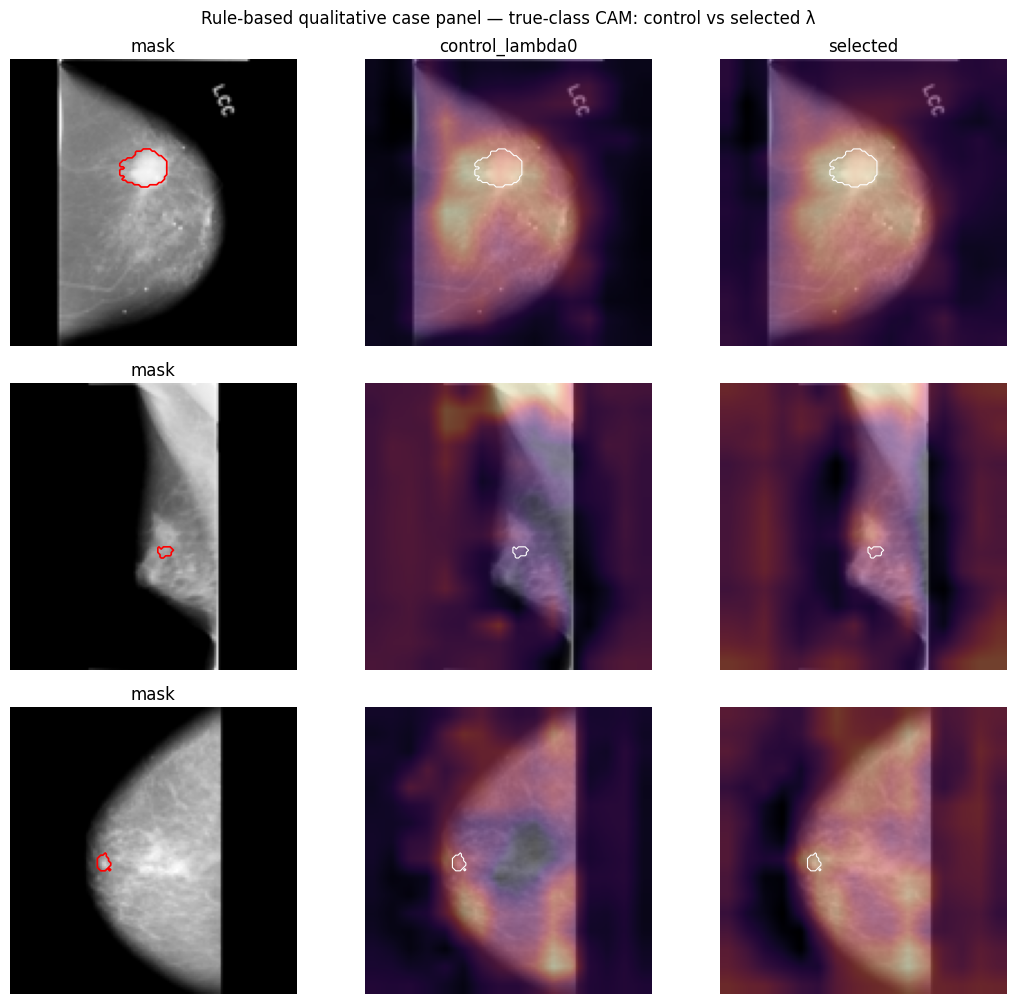

In [17]:
sel_tp=final["selected"]["pred"].merge(test_df[["sample_id","label","has_malignant_mask"]],on="sample_id")
sel_tp=sel_tp[(sel_tp.label==1)&(sel_tp.has_malignant_mask)]
th=final["selected"]["threshold"]
picks=[]
correct=sel_tp[sel_tp.p_malignant>=th].sort_values("p_malignant",ascending=False)
wrong  =sel_tp[sel_tp.p_malignant< th].sort_values("p_malignant")
border =sel_tp.assign(d=(sel_tp.p_malignant-th).abs()).sort_values("d")
for pool in (correct,wrong,border):
    if len(pool): picks.append(pool.iloc[0].sample_id)
picks=list(dict.fromkeys(picks))

def overlay(gray,cam):
    g=np.array(gray,float)/255.; return np.clip(0.55*np.dstack([g,g,g])+0.45*matplotlib.colormaps["magma"](cam)[:,:,:3],0,1)
mods={t:ConvNeXtCAM2().to(device) for t in ["control_lambda0","selected"]}
for t in mods: mods[t].load_state_dict(torch.load(models_by_lambda[final[t]["lambda"]],map_location=device)); mods[t].eval()
if picks:
    fig,ax=plt.subplots(len(picks),3,figsize=(11,3.4*len(picks)))
    if len(picks)==1: ax=ax[None,:]
    for r,sid in enumerate(picks):
        img=Image.open(ip(sid)).convert("L").resize((SUP_SIZE,SUP_SIZE))
        mask=np.array(Image.open(mp_(sid)).convert("L").resize((SUP_SIZE,SUP_SIZE),RESAMPLE_NEAREST))>127
        ax[r,0].imshow(img,cmap="gray"); ax[r,0].contour(mask,levels=[.5],colors="red",linewidths=1.2); ax[r,0].set_title("mask"); ax[r,0].axis("off")
        t=torch.from_numpy(np.stack([np.array(Image.open(ip(sid)).convert("L"),np.float32)/255.]*3,0)); t=(t-MEAN)/STD
        for k,tag in enumerate(["control_lambda0","selected"]):
            cam=cam_map(mods[tag],t.float(),1)
            ax[r,k+1].imshow(overlay(img,cam)); ax[r,k+1].contour(mask,levels=[.5],colors="white",linewidths=.8)
            ax[r,k+1].set_title(f"{tag}" if r==0 else ""); ax[r,k+1].axis("off")
    plt.suptitle("Rule-based qualitative case panel — true-class CAM: control vs selected λ"); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"qualitative_panel.png"),dpi=200,bbox_inches="tight"); plt.show()

## 15. Central claim & honest framing

Interpret classification and localisation together.

- If a selected λ > 0 improves localisation while preserving classification
  within the predefined tolerance, the result supports the claim that
  ROI-guided attention supervision generalises beyond ResNet-50.
- If λ = 0 is selected, or localisation does not improve, report that the
  ResNet finding did not reproduce on ConvNeXt-Tiny under this protocol.
- Do not claim universal improvement from a higher raw score alone; use the
  paired patient-level confidence intervals and the predefined validation rule.
- This notebook is a backbone-generalisation experiment, not a new method or a
  redesign of the dissertation.
